# ClimateTwin V2 — Reference Solution Notebook

**Instructor reference implementation for AquaAir General Insurance**

This notebook is aligned to the frozen V2 data contract. It:

- does **not** suppress warnings globally;
- audits the claim-level insurance mechanics before modelling;
- models exposure-adjusted frequency on `dataset.csv`;
- models strictly positive claim-level **covered severity** on `claim_level_data.csv`;
- converts covered severity to insurer-paid loss by applying the deductible once and then the per-claim limit;
- runs the four required scenarios with reproducible Monte Carlo simulation;
- uses repeated seeds to quantify Monte Carlo uncertainty around VaR/TVaR; and
- evaluates a finite set of feasible mitigation candidates without claiming a global optimum.

> The uncertainty intervals in this notebook measure **Monte Carlo simulation uncertainty only**. They do not include parameter, model-form, or DGP uncertainty.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

DATA_PATH = Path("dataset.csv")
CLAIM_PATH = Path("claim_level_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("dataset.csv not found. Keep it in the same folder as this notebook.")
if not CLAIM_PATH.exists():
    raise FileNotFoundError(
        "claim_level_data.csv not found. It is generated by the V2 data_script.py and is required "
        "for the instructor reference severity model."
    )

SEED = 20260915
RESILIENCE_BUDGET = 8_000_000
FIXED_EXPENSE = 750.0
VARIABLE_EXPENSE_RATIO = 0.25
PROFIT_CONTINGENCY = 0.05

df = pd.read_csv(DATA_PATH)
claims = pd.read_csv(CLAIM_PATH)

print("Policy-year table:", df.shape)
print("Claim-level table:", claims.shape)
print("Years:", sorted(df["year"].unique()))
print("Unique locations:", df["location_id"].nunique())


Policy-year table: (750, 35)
Claim-level table: (95, 18)
Years: [np.int64(2024), np.int64(2025), np.int64(2026)]
Unique locations: 250


## 0. Contract mechanics and worked checks

The V2 calculation order is:

1. ground-up remediation / extra expense;
2. ground-up BI;
3. BI waiting period applied **only** to BI;
4. total covered loss;
5. deductible applied **once** to total covered loss;
6. per-claim policy limit.

A valid claim can therefore have positive covered loss but zero insurer payment.


In [2]:
def apply_policy_terms(remediation_loss, daily_bi_loss, interruption_days,
                       waiting_days, deductible, policy_limit):
    ground_up_bi = daily_bi_loss * interruption_days
    covered_bi_days = max(interruption_days - waiting_days, 0)
    covered_bi = daily_bi_loss * covered_bi_days
    ground_up = remediation_loss + ground_up_bi
    covered = remediation_loss + covered_bi
    after_deductible = max(covered - deductible, 0.0)
    paid = min(after_deductible, policy_limit)
    return {
        "ground_up_bi_loss": ground_up_bi,
        "covered_bi_loss": covered_bi,
        "ground_up_loss": ground_up,
        "covered_loss": covered,
        "loss_after_deductible": after_deductible,
        "paid_loss": paid,
    }

worked_examples = pd.DataFrame({
    "Below deductible": apply_policy_terms(20_000, 0, 0, 2, 50_000, 500_000),
    "Limited payment": apply_policy_terms(900_000, 0, 0, 2, 50_000, 400_000),
    "BI waiting not met": apply_policy_terms(100_000, 30_000, 2, 3, 50_000, 500_000),
}).T

worked_examples


,ground_up_bi_loss,covered_bi_loss,ground_up_loss,covered_loss,loss_after_deductible,paid_loss
Below deductible,0.0,0.0,20000.0,20000.0,0.0,0.0
Limited payment,0.0,0.0,900000.0,900000.0,850000.0,400000.0
BI waiting not met,60000.0,0.0,160000.0,100000.0,50000.0,50000.0


In [3]:
# Audit the frozen claim-level table against the V2 contract formulas.
eps = 0.02

expected_covered_bi = []
for r in claims.itertuples(index=False):
    # infer daily BI from ground-up BI / interruption days where applicable
    daily = 0.0 if r.interruption_days == 0 else r.ground_up_bi_loss / r.interruption_days
    expected_covered_bi.append(daily * max(r.interruption_days - r.bi_waiting_period_days, 0))

expected_covered_bi = np.array(expected_covered_bi)
expected_covered = claims["ground_up_remediation_loss"].to_numpy() + expected_covered_bi
expected_after_ded = np.maximum(expected_covered - claims["deductible"].to_numpy(), 0)
expected_paid = np.minimum(expected_after_ded, claims["policy_limit"].to_numpy())

checks = {
    "covered_loss_positive": bool((claims["covered_loss"] > 0).all()),
    "zero_paid_claims_present": int((claims["paid_loss"] == 0).sum()),
    "covered_bi_rule_matches": bool(np.allclose(claims["covered_bi_loss"], expected_covered_bi, atol=eps)),
    "covered_total_matches": bool(np.allclose(claims["covered_loss"], expected_covered, atol=eps)),
    "deductible_applied_once": bool(np.allclose(claims["loss_after_deductible"], expected_after_ded, atol=eps)),
    "limit_applied": bool(np.allclose(claims["paid_loss"], expected_paid, atol=eps)),
    "payment_never_exceeds_limit": bool((claims["paid_loss"] <= claims["policy_limit"] + eps).all()),
}
pd.Series(checks)


covered_loss_positive          True
zero_paid_claims_present         33
covered_bi_rule_matches        True
covered_total_matches          True
deductible_applied_once        True
limit_applied                  True
payment_never_exceeds_limit    True
dtype: object

## 1. Feature engineering and baseline diagnostics

The insured-trigger fields are retained for coverage auditing, but they are **not** used as the sole predictors in the core frequency model. The modelling features are environmental/climate, portfolio, and mitigation variables observable before the claim outcome.


In [4]:
def add_model_features(data):
    x = data.copy()
    x["pm25_10"] = x["pm25"] / 10.0
    x["ozone_10"] = x["ozone"] / 10.0
    x["turbidity_2"] = x["turbidity"] / 2.0
    x["wqi_10"] = x["water_quality_index"] / 10.0
    x["temp_5"] = x["temperature_c"] / 5.0
    x["rain_500"] = x["annual_rainfall_mm"] / 500.0
    x["log_insured_value"] = np.log(x["insured_value"])
    x["air_water_stress_interaction"] = x["air_stress_flag"] * x["water_stress_flag"]
    return x

dfm = add_model_features(df)

portfolio_summary = pd.Series({
    "rows": len(df),
    "unique_locations": df["location_id"].nunique(),
    "total_exposure": df["exposure_years"].sum(),
    "claims": df["claim_count"].sum(),
    "claim_frequency_per_exposure": df["claim_count"].sum() / df["exposure_years"].sum(),
    "claim_positive_policy_years": int((df["claim_count"] > 0).sum()),
    "zero_paid_claims": int((claims["paid_loss"] == 0).sum()),
    "total_ground_up_loss": df["aggregate_ground_up_loss"].sum(),
    "total_covered_loss": df["aggregate_covered_loss"].sum(),
    "total_paid_loss": df["aggregate_paid_loss"].sum(),
})
portfolio_summary


rows                            7.500000e+02
unique_locations                2.500000e+02
total_exposure                  6.420680e+02
claims                          9.500000e+01
claim_frequency_per_exposure    1.479594e-01
claim_positive_policy_years     7.100000e+01
zero_paid_claims                3.300000e+01
total_ground_up_loss            1.228736e+07
total_covered_loss              7.747945e+06
total_paid_loss                 3.480013e+06
dtype: float64

In [5]:
coverage_audit = pd.DataFrame({
    "Air stress rows": [int(df["air_stress_flag"].sum())],
    "Air trigger rows": [int(df["air_trigger_flag"].sum())],
    "Water stress rows": [int(df["water_stress_flag"].sum())],
    "Water trigger rows": [int(df["water_trigger_flag"].sum())],
    "Compound trigger rows": [int(df["compound_trigger_flag"].sum())],
})
coverage_audit


,Air stress rows,Air trigger rows,Water stress rows,Water trigger rows,Compound trigger rows
0,381,94,338,73,9


**Interpretation checkpoint.** Environmental stress is more common than qualifying insured triggers, and qualifying triggers need not produce insurer payment. This distinction is the core hazard-to-claim lesson.


## 2. Exposure-adjusted frequency model

The reference model is a Poisson GLM with `log(exposure_years)` as an offset. We capture and display fitting warnings rather than hiding them.


In [6]:
freq_formula = (
    "claim_count ~ C(occupancy) + C(region) "
    "+ pm25_10 + ozone_10 + turbidity_2 + wqi_10 "
    "+ temp_5 + rain_500 + drought_indicator "
    "+ air_water_stress_interaction "
    "+ air_filtration + water_treatment + business_continuity_plan"
)

with warnings.catch_warnings(record=True) as freq_warnings:
    warnings.simplefilter("always")
    freq_model = smf.glm(
        formula=freq_formula,
        data=dfm,
        family=sm.families.Poisson(),
        offset=np.log(dfm["exposure_years"]),
    ).fit()

print("Converged:", freq_model.converged)
print("Pearson dispersion:", round(freq_model.pearson_chi2 / freq_model.df_resid, 3))
print("Deviance / df:", round(freq_model.deviance / freq_model.df_resid, 3))
print("Warnings captured:", len(freq_warnings))
for w in freq_warnings:
    print(f"- {w.category.__name__}: {w.message}")

if not freq_model.converged:
    raise RuntimeError("Frequency GLM did not converge.")
if not np.isfinite(freq_model.params).all():
    raise RuntimeError("Frequency GLM contains non-finite coefficients.")

rate_ratios = pd.DataFrame({
    "coefficient": freq_model.params,
    "rate_ratio": np.exp(freq_model.params),
    "p_value": freq_model.pvalues,
}).sort_values("p_value")
rate_ratios.head(12)


Converged: True
Pearson dispersion: 1.329
Deviance / df: 0.51
Warnings captured: 0


,coefficient,rate_ratio,p_value
turbidity_2,0.574320,1.775923,0.002464
C(region)[T.Coastview],-3.041764,0.047751,0.003365
C(region)[T.Northgate],-1.511439,0.220592,0.013142
C(region)[T.Riverbend],-1.832955,0.159940,0.020572
water_treatment,-0.524765,0.591695,0.028657
C(region)[T.Drylands],-1.272545,0.280118,0.033495
C(occupancy)[T.Hospital],0.627256,1.872465,0.034010
air_filtration,-0.426974,0.652481,0.057912
ozone_10,-0.274168,0.760205,0.061833
business_continuity_plan,-0.430923,0.649909,0.065658


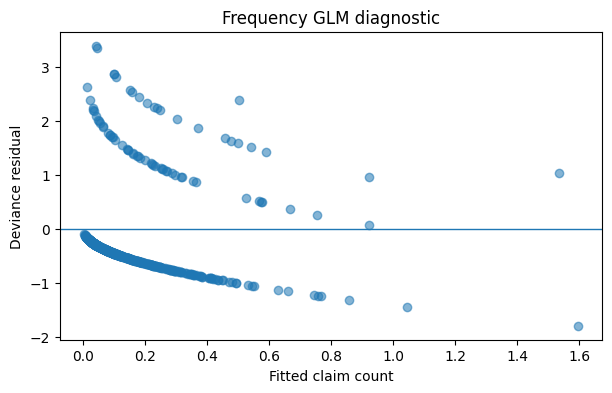

In [7]:
# Simple residual diagnostic: fitted count vs deviance residual.
plt.figure(figsize=(7, 4))
plt.scatter(freq_model.fittedvalues, freq_model.resid_deviance, alpha=0.55)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted claim count")
plt.ylabel("Deviance residual")
plt.title("Frequency GLM diagnostic")
plt.show()


**Diagnostic interpretation.** The Poisson dispersion statistic should be read as a modelling diagnostic, not as proof that the Poisson DGP is exact. Material overdispersion would motivate a Negative Binomial sensitivity analysis. The reference model is kept deliberately interpretable for the teaching objective.


## 3. Claim-level covered severity model

The reference solution uses `claim_level_data.csv` and models **covered loss**, which is strictly positive. It does not fit Gamma directly to paid loss because the V2 contract legitimately produces zero-paid claims after the deductible.


In [8]:
policy_for_claims = df.drop(columns=[
    "claim_count", "aggregate_ground_up_loss", "aggregate_covered_loss", "aggregate_paid_loss"
])

clm = claims.merge(
    policy_for_claims,
    on=["policy_id", "location_id", "year"],
    how="left",
    suffixes=("_claim", ""),
)
clm = add_model_features(clm)

assert (clm["covered_loss"] > 0).all()
print("Claim-level observations:", len(clm))
print("Minimum covered loss:", clm["covered_loss"].min())
print("Zero paid claims retained:", int((clm["paid_loss"] == 0).sum()))

sev_formula = (
    "covered_loss ~ log_insured_value + C(occupancy) "
    "+ pm25_10 + ozone_10 + turbidity_2 + wqi_10 "
    "+ temp_5 + drought_indicator + air_water_stress_interaction "
    "+ air_filtration + water_treatment + business_continuity_plan "
    "+ bi_waiting_period_days"
)

with warnings.catch_warnings(record=True) as sev_warnings:
    warnings.simplefilter("always")
    sev_model = smf.glm(
        formula=sev_formula,
        data=clm,
        family=sm.families.Gamma(link=sm.families.links.Log()),
    ).fit()

print("Converged:", sev_model.converged)
print("Gamma dispersion/scale:", round(float(sev_model.scale), 4))
print("Warnings captured:", len(sev_warnings))
for w in sev_warnings:
    print(f"- {w.category.__name__}: {w.message}")

if not sev_model.converged:
    raise RuntimeError("Severity GLM did not converge.")
if not np.isfinite(sev_model.params).all():
    raise RuntimeError("Severity GLM contains non-finite coefficients.")

sev_effects = pd.DataFrame({
    "coefficient": sev_model.params,
    "multiplicative_effect": np.exp(sev_model.params),
    "p_value": sev_model.pvalues,
}).sort_values("p_value")
sev_effects.head(12)


Claim-level observations: 95
Minimum covered loss: 12878.08
Zero paid claims retained: 33
Converged: True
Gamma dispersion/scale: 0.4688
Warnings captured: 0


,coefficient,multiplicative_effect,p_value
bi_waiting_period_days,-0.332112,0.717407,0.004146
log_insured_value,0.465492,1.592798,0.015289
Intercept,4.470080,87.363713,0.196544
pm25_10,0.175560,1.191914,0.223652
turbidity_2,0.092389,1.096791,0.387358
air_water_stress_interaction,0.148651,1.160268,0.462835
ozone_10,-0.076208,0.926624,0.486137
drought_indicator,-0.291952,0.746804,0.520546
wqi_10,-0.069147,0.933189,0.546341
temp_5,-0.057536,0.944088,0.675342


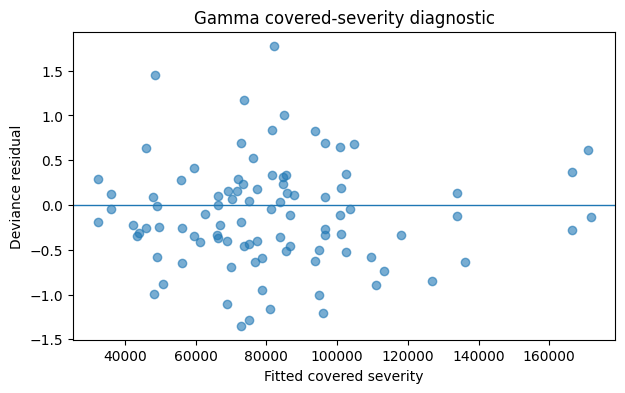

In [9]:
plt.figure(figsize=(7, 4))
plt.scatter(sev_model.fittedvalues, sev_model.resid_deviance, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted covered severity")
plt.ylabel("Deviance residual")
plt.title("Gamma covered-severity diagnostic")
plt.show()


**Meaningful warning policy.** This notebook does not call `warnings.filterwarnings("ignore")`. If statsmodels emits a convergence, overflow, invalid-value, or perfect-separation warning, it is displayed and should be investigated. Benign library deprecation warnings should be documented rather than globally hidden.


## 4. Scenario and simulation helpers

The fitted severity model predicts covered severity **after the waiting-period rule**. The Monte Carlo layer then applies deductible and limit claim by claim. The Gamma simulation uses the fitted GLM scale: for a Gamma GLM, `Var(Y|X) = phi × mu²`, so the equivalent simulation shape is approximately `1/phi`.

The scenario helper changes environmental variables and recomputes stress flags. It does not force claims.


In [10]:
def apply_scenario(portfolio, scenario):
    p = portfolio.copy()
    if scenario in ("Air stress", "Compound stress"):
        p["pm25"] = p["pm25"] + 15.0
        p["ozone"] = p["ozone"] + 10.0
    if scenario in ("Water stress", "Compound stress"):
        p["turbidity"] = p["turbidity"] * 1.60
        p["water_quality_index"] = np.maximum(p["water_quality_index"] - 15.0, 0.0)

    p["air_stress_flag"] = ((p["pm25"] >= 35.0) | (p["ozone"] >= 70.0)).astype(int)
    p["water_stress_flag"] = ((p["turbidity"] >= 5.0) | (p["water_quality_index"] <= 60.0)).astype(int)
    return add_model_features(p)


def predict_portfolio(portfolio):
    p = add_model_features(portfolio)
    p["mu_count"] = freq_model.predict(p, offset=np.log(p["exposure_years"]))
    p["mu_covered"] = sev_model.predict(p)

    if not np.isfinite(p[["mu_count", "mu_covered"]].to_numpy()).all():
        raise ValueError("Non-finite portfolio predictions.")
    if (p[["mu_count", "mu_covered"]] < 0).any().any():
        raise ValueError("Negative model prediction.")
    return p


def simulate_paid_portfolio(predicted_portfolio, n_sims=20_000, seed=SEED):
    rng = np.random.default_rng(seed)
    totals = np.zeros(n_sims, dtype=float)

    phi = max(float(sev_model.scale), 1e-9)
    gamma_shape = 1.0 / phi

    for row in predicted_portfolio.itertuples(index=False):
        counts = rng.poisson(max(float(row.mu_count), 0.0), size=n_sims)
        n_claims = int(counts.sum())
        if n_claims == 0:
            continue

        covered = rng.gamma(
            shape=gamma_shape,
            scale=max(float(row.mu_covered), 1e-9) / gamma_shape,
            size=n_claims,
        )
        paid = np.minimum(np.maximum(covered - float(row.deductible), 0.0), float(row.policy_limit))

        sim_index = np.repeat(np.arange(n_sims), counts)
        np.add.at(totals, sim_index, paid)

    if not np.isfinite(totals).all():
        raise ValueError("Simulation produced non-finite annual losses.")
    return totals


def tail_metrics(losses, alpha=0.99):
    var = float(np.quantile(losses, alpha))
    tail = losses[losses >= var]
    return {
        "mean_paid_loss": float(np.mean(losses)),
        "VaR_99": var,
        "TVaR_99": float(np.mean(tail)),
    }


def pricing_metrics(losses, portfolio):
    m = tail_metrics(losses)
    exposure = float(portfolio["exposure_years"].sum())
    current_premium = float(portfolio["current_premium"].sum())
    indicated = (m["mean_paid_loss"] + FIXED_EXPENSE * exposure) / (
        1 - VARIABLE_EXPENSE_RATIO - PROFIT_CONTINGENCY
    )
    m.update({
        "exposure": exposure,
        "current_premium": current_premium,
        "indicated_premium": indicated,
        "adequacy_ratio": current_premium / indicated,
    })
    return m


## 5. Baseline and four-scenario comparison

The same simulation seed is used across scenarios (common-random-number idea) to reduce irrelevant Monte Carlo noise in comparative results.


In [11]:
portfolio_2026 = df.loc[df["year"] == 2026].copy()
SCENARIOS = ["Baseline", "Air stress", "Water stress", "Compound stress"]

scenario_results = {}
rows = []

for scenario in SCENARIOS:
    scenario_port = apply_scenario(portfolio_2026, scenario)
    pred = predict_portfolio(scenario_port)
    losses = simulate_paid_portfolio(pred, n_sims=20_000, seed=SEED)
    metrics = pricing_metrics(losses, scenario_port)
    scenario_results[scenario] = {"portfolio": scenario_port, "pred": pred, "losses": losses, "metrics": metrics}
    rows.append({"scenario": scenario, **metrics})

scenario_table = pd.DataFrame(rows).set_index("scenario")
scenario_table[["mean_paid_loss", "indicated_premium", "current_premium", "adequacy_ratio", "VaR_99", "TVaR_99"]].round(2)


,mean_paid_loss,indicated_premium,current_premium,adequacy_ratio,VaR_99,TVaR_99
scenario,,,,,,
Baseline,1579995.52,2486667.53,14130800.0,5.68,2886835.57,3133296.59
Air stress,2795165.95,4222625.29,14130800.0,3.35,4662297.31,5019203.97
Water stress,11233830.43,16277860.25,14130800.0,0.87,14999369.84,15675254.10
Compound stress,19741145.53,28431167.55,14130800.0,0.50,25196709.35,25988897.73


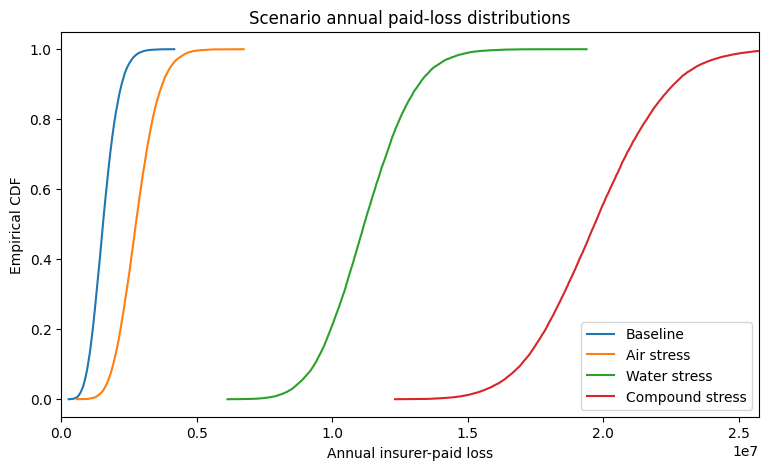

In [12]:
plt.figure(figsize=(9, 5))
for scenario in SCENARIOS:
    x = np.sort(scenario_results[scenario]["losses"])
    y = np.linspace(0, 1, len(x), endpoint=False)
    plt.plot(x, y, label=scenario)
plt.xlim(0, max(np.quantile(scenario_results[s]["losses"], 0.995) for s in SCENARIOS))
plt.xlabel("Annual insurer-paid loss")
plt.ylabel("Empirical CDF")
plt.title("Scenario annual paid-loss distributions")
plt.legend()
plt.show()


## 6. Monte Carlo uncertainty around tail-risk rankings

TVaR uses only the extreme tail, so a single simulation run can create false precision. We therefore repeat each scenario over several independent seeds. The interval below is an approximate 95% interval for the **Monte Carlo estimate** based on between-seed variation; it is not a model-parameter confidence interval.


In [13]:
def repeated_tail_estimates(portfolio, seeds, n_sims_per_seed=8_000):
    pred = predict_portfolio(portfolio)
    out = []
    for s in seeds:
        losses = simulate_paid_portfolio(pred, n_sims=n_sims_per_seed, seed=int(s))
        out.append({"seed": s, **tail_metrics(losses)})
    return pd.DataFrame(out)


UNCERTAINTY_SEEDS = [4101, 4102, 4103, 4104, 4105, 4106]
unc_rows = []

for scenario in SCENARIOS:
    reps = repeated_tail_estimates(apply_scenario(portfolio_2026, scenario), UNCERTAINTY_SEEDS)
    mean_t = reps["TVaR_99"].mean()
    se_t = reps["TVaR_99"].std(ddof=1) / np.sqrt(len(reps))
    unc_rows.append({
        "scenario": scenario,
        "TVaR_mean_across_seeds": mean_t,
        "TVaR_MC_SE": se_t,
        "TVaR_MC_low_95": mean_t - 1.96 * se_t,
        "TVaR_MC_high_95": mean_t + 1.96 * se_t,
        "VaR_mean_across_seeds": reps["VaR_99"].mean(),
    })

scenario_uncertainty = pd.DataFrame(unc_rows).set_index("scenario")
scenario_uncertainty.round(2)


,TVaR_mean_across_seeds,TVaR_MC_SE,TVaR_MC_low_95,TVaR_MC_high_95,VaR_mean_across_seeds
scenario,,,,,
Baseline,3107996.48,24275.00,3060417.48,3155575.47,2880558.58
Air stress,5015744.47,14328.42,4987660.76,5043828.17,4664828.70
Water stress,15593569.43,43212.70,15508872.54,15678266.31,14971284.23
Compound stress,25919949.35,47417.81,25827010.44,26012888.26,25059444.50


**Interpretation rule.** A ranking is most persuasive when the TVaR differences are large relative to their Monte Carlo uncertainty. Overlapping intervals do not prove equality, but they are a warning against presenting tiny differences as decisive.


## 7. Candidate mitigation portfolios under the 8,000,000 budget

This section deliberately evaluates a **finite candidate set**. It does not solve or claim a global optimization problem.

To keep candidate construction transparent, we create action-level proxies from the fitted models and then form five candidate strategies:

- no new action;
- air-filtration priority;
- water-treatment priority;
- BCP priority;
- balanced expected-loss-reduction-per-cost;
- largest expected-loss-reduction first.

The final decision is made from simulated TVaR among these feasible candidates, with repeated seeds used to check ranking stability.


In [14]:
compound_port = apply_scenario(portfolio_2026, "Compound stress")


def proxy_expected_paid(predicted):
    # Deterministic ranking proxy only. Final evaluation uses Monte Carlo.
    approx_paid_sev = np.minimum(
        np.maximum(predicted["mu_covered"] - predicted["deductible"], 0.0),
        predicted["policy_limit"],
    )
    return predicted["mu_count"] * approx_paid_sev


def build_action_table(base_portfolio):
    base = base_portfolio.copy().reset_index(drop=True)
    base_pred = predict_portfolio(base)
    base_proxy = proxy_expected_paid(base_pred).to_numpy()
    actions = []

    specs = [
        ("Air filtration", "air_filtration", "air_filtration_upgrade_cost"),
        ("Water treatment", "water_treatment", "water_treatment_upgrade_cost"),
        ("BCP", "business_continuity_plan", "bcp_upgrade_cost"),
    ]

    for action_name, flag, cost_col in specs:
        eligible = base.index[(base[flag] == 0) & (base[cost_col] > 0)].to_numpy()
        if len(eligible) == 0:
            continue
        modified_rows = base.loc[eligible].copy()
        modified_rows[flag] = 1
        mod_pred = predict_portfolio(modified_rows)
        mod_proxy = proxy_expected_paid(mod_pred).to_numpy()

        for j, row_idx in enumerate(eligible):
            reduction = max(float(base_proxy[row_idx] - mod_proxy[j]), 0.0)
            cost = float(base.loc[row_idx, cost_col])
            actions.append({
                "location_id": base.loc[row_idx, "location_id"],
                "action": action_name,
                "flag": flag,
                "cost": cost,
                "proxy_loss_reduction": reduction,
                "proxy_bcr": reduction / cost if cost > 0 else 0.0,
                "base_proxy_risk": float(base_proxy[row_idx]),
            })
    return pd.DataFrame(actions)


actions = build_action_table(compound_port)
print("Available upgrade actions:", len(actions))
actions.head()


Available upgrade actions: 429


,location_id,action,flag,cost,proxy_loss_reduction,proxy_bcr,base_proxy_risk
0,LOC001,Air filtration,air_filtration,88000.0,94755.499421,1.076767,286277.685336
1,LOC003,Air filtration,air_filtration,95000.0,33694.184229,0.354676,101908.712158
2,LOC004,Air filtration,air_filtration,109000.0,37953.815119,0.348200,117079.599241
3,LOC006,Air filtration,air_filtration,88000.0,13304.200877,0.151184,40143.886368
4,LOC007,Air filtration,air_filtration,87000.0,12396.015396,0.142483,37866.938224


In [15]:
def greedy_select(action_table, sort_col, budget=RESILIENCE_BUDGET, allowed_action=None):
    a = action_table.copy()
    if allowed_action is not None:
        a = a[a["action"] == allowed_action].copy()
    a = a.sort_values(sort_col, ascending=False)

    selected = []
    spent = 0.0
    for r in a.itertuples(index=False):
        if spent + r.cost <= budget:
            selected.append(r)
            spent += r.cost
    return pd.DataFrame(selected)


candidate_actions = {
    "No new mitigation": actions.iloc[0:0].copy(),
    "Air priority": greedy_select(actions, "proxy_bcr", allowed_action="Air filtration"),
    "Water priority": greedy_select(actions, "proxy_bcr", allowed_action="Water treatment"),
    "BCP priority": greedy_select(actions, "proxy_bcr", allowed_action="BCP"),
    "Balanced BCR": greedy_select(actions, "proxy_bcr"),
    "Largest reduction first": greedy_select(actions, "proxy_loss_reduction"),
}


def apply_actions(portfolio, selected):
    p = portfolio.copy().reset_index(drop=True)
    if selected.empty:
        return p
    loc_to_idx = {loc: i for i, loc in enumerate(p["location_id"])}
    for r in selected.itertuples(index=False):
        p.loc[loc_to_idx[r.location_id], r.flag] = 1
    return p


pd.DataFrame({
    name: {
        "actions": len(sel),
        "cost": float(sel["cost"].sum()) if not sel.empty else 0.0,
    }
    for name, sel in candidate_actions.items()
}).T


,actions,cost
No new mitigation,0.0,0.0
Air priority,85.0,7988000.0
Water priority,65.0,7983000.0
BCP priority,146.0,7625000.0
Balanced BCR,91.0,7975000.0
Largest reduction first,78.0,7972000.0


In [16]:
# Main candidate comparison using a larger common seed run.
candidate_main = {}
for name, selected in candidate_actions.items():
    p = apply_actions(compound_port, selected)
    pred = predict_portfolio(p)
    losses = simulate_paid_portfolio(pred, n_sims=20_000, seed=SEED)
    m = pricing_metrics(losses, p)
    candidate_main[name] = {"portfolio": p, "selected": selected, "losses": losses, "metrics": m}

baseline_candidate = candidate_main["No new mitigation"]["metrics"]

candidate_rows = []
for name, obj in candidate_main.items():
    m = obj["metrics"]
    cost = float(obj["selected"]["cost"].sum()) if not obj["selected"].empty else 0.0
    loss_reduction = baseline_candidate["mean_paid_loss"] - m["mean_paid_loss"]
    candidate_rows.append({
        "strategy": name,
        "cost": cost,
        "mean_paid_loss": m["mean_paid_loss"],
        "expected_loss_reduction": loss_reduction,
        "benefit_cost_ratio": loss_reduction / cost if cost > 0 else np.nan,
        "VaR_99": m["VaR_99"],
        "TVaR_99": m["TVaR_99"],
        "TVaR_reduction": baseline_candidate["TVaR_99"] - m["TVaR_99"],
        "adequacy_ratio": m["adequacy_ratio"],
    })

candidate_table = pd.DataFrame(candidate_rows).set_index("strategy").sort_values("TVaR_99")
candidate_table.round(2)


,cost,mean_paid_loss,expected_loss_reduction,benefit_cost_ratio,VaR_99,TVaR_99,TVaR_reduction,adequacy_ratio
strategy,,,,,,,,
Balanced BCR,7975000.0,13002128.31,6739017.22,0.85,17383675.71,18165898.50,7822999.23,0.75
Largest reduction first,7972000.0,13165552.95,6575592.58,0.82,17537823.78,18320881.18,7668016.55,0.74
Water priority,7983000.0,15065957.84,4675187.69,0.59,19742247.01,20559437.33,5429460.40,0.65
Air priority,7988000.0,15697630.89,4043514.64,0.51,20657145.39,21509315.45,4479582.28,0.62
BCP priority,7625000.0,16350870.38,3390275.16,0.44,21519148.61,22306714.00,3682183.73,0.60
No new mitigation,0.0,19741145.53,0.00,NaN,25196709.35,25988897.73,0.00,0.50


In [17]:
# Ranking stability across repeated seeds, using the same seeds for every strategy.
MITIGATION_SEEDS = [5101, 5102, 5103, 5104, 5105, 5106]
records = []

for s in MITIGATION_SEEDS:
    seed_rows = []
    for name, obj in candidate_main.items():
        losses = simulate_paid_portfolio(
            predict_portfolio(obj["portfolio"]),
            n_sims=8_000,
            seed=s,
        )
        t = tail_metrics(losses)["TVaR_99"]
        seed_rows.append((name, t))
        records.append({"seed": s, "strategy": name, "TVaR_99": t})
    # rank 1 = lowest estimated TVaR among evaluated candidates
ranking_df = pd.DataFrame(records)
ranking_df["rank"] = ranking_df.groupby("seed")["TVaR_99"].rank(method="min", ascending=True)

mitigation_uncertainty = ranking_df.groupby("strategy").agg(
    TVaR_mean=("TVaR_99", "mean"),
    TVaR_sd=("TVaR_99", "std"),
    best_rank_count=("rank", lambda x: int((x == 1).sum())),
).sort_values("TVaR_mean")

mitigation_uncertainty["TVaR_MC_SE"] = mitigation_uncertainty["TVaR_sd"] / np.sqrt(len(MITIGATION_SEEDS))
mitigation_uncertainty["TVaR_MC_low_95"] = mitigation_uncertainty["TVaR_mean"] - 1.96 * mitigation_uncertainty["TVaR_MC_SE"]
mitigation_uncertainty["TVaR_MC_high_95"] = mitigation_uncertainty["TVaR_mean"] + 1.96 * mitigation_uncertainty["TVaR_MC_SE"]
mitigation_uncertainty.round(2)


,TVaR_mean,TVaR_sd,best_rank_count,TVaR_MC_SE,TVaR_MC_low_95,TVaR_MC_high_95
strategy,,,,,,
Balanced BCR,18063370.05,94866.01,6,38728.89,17987461.44,18139278.67
Largest reduction first,18312340.29,127015.20,0,51853.74,18210706.96,18413973.62
Water priority,20495213.80,146908.25,0,59975.04,20377662.72,20612764.88
Air priority,21382487.57,161424.41,0,65901.24,21253321.14,21511654.00
BCP priority,22119023.64,169136.65,0,69049.75,21983686.13,22254361.15
No new mitigation,25895391.89,114259.34,0,46646.18,25803965.38,25986818.40


### Decision wording

Use the candidate table and the repeated-seed stability table above. The correct form is:

> **Among the feasible candidate portfolios evaluated under the stated 8,000,000 budget, [strategy] had the lowest estimated TVaR99 in the reference comparison.**

If the repeated-seed ranking is unstable or the Monte Carlo intervals overlap materially, say so explicitly. Do **not** write “this is the optimal mitigation portfolio” unless a true optimization over the complete feasible action space has actually been performed.


## 8. Final Climate Risk Committee recommendation — reference structure

A strong memo should contain:

1. **Baseline position:** expected paid loss, indicated premium, adequacy ratio, VaR99, TVaR99.
2. **Most material stress:** identify the scenario with the largest financially relevant deterioration and quantify the change from baseline.
3. **Mitigation:** identify the best-performing **evaluated candidate**, its cost, expected-loss reduction, TVaR reduction, and Monte Carlo ranking stability.
4. **Action:** Maintain / Reprice / Mitigate / Restrict / Monitor, with a short business rationale.
5. **Limitations:** at minimum:
   - synthetic data and simplified coverage;
   - model-form/parameter uncertainty not represented by the Monte Carlo intervals;
   - scenario transforms are stylized rather than forecasts;
   - V2 air/water trigger draws are conditionally independent given covariates, with compound non-additivity introduced explicitly rather than through a copula/common-shock/spatial process;
   - mitigation effects are instructional assumptions and not causal estimates.

The committee should not confuse environmental severity with insured financial severity.
